# Spectroscopic Data Reduction Part 3: Extracting the final wavelength-calibrated spectrum 

This tutorial assumes you have gone through the [Trace](1-SpectroscopicTraceTutorial.ipynb) and [Wavelength Calibration](2-WavelengthCalibration) tutorials and have their results available.

## Authors
Adam Ginsburg, Kelle Cruz, Lia Corrales, Jonathan Sick, Adrian Price-Whelan

## Learning Goals
* Extract a target 1D spectrum from a two-dimensional spectrum using an existing trace
* Apply a fitted wavelength solution to the data
* Fit a line profile to the wavelength-calibrated spectrum

## Keywords
Spectroscopy

## Summary
This tutorial, the third in a series, shows how to apply a trace and a wavelength solution to science data.  It then shows how to do basic analysis, i.e., line fitting.

In [17]:
with open('requirements.txt') as f:
    print(f"Required packages for this notebook:\n{f.read()}")

Required packages for this notebook:
astropy
astroquery>=0.4.8.dev9474  # 2024-09-24 pinned for Gaia column capitalization issue
IPython
numpy
pillow
matplotlib



## Extract the science spectrum

First, we repeat the trace-and-extract process derived in [Part 1](1-SpectroscopicTraceTutorial.ipynb), but now for Deneb:

In [138]:
from PIL import Image as PILImage
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

In [139]:
from astropy.modeling.models import Linear1D
from astropy import constants
from astropy import units as u
from astropy.visualization import quantity_support
quantity_support() # activar soporte de unidades

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x7f7178242910>

In [140]:
deneb = np.array(PILImage.open('deneb_3s_1.bmp'))
print(deneb.shape)

(1200, 1600)


In [141]:
aldebaran = np.array(PILImage.open('aldebaran_3s_1.bmp'))
print(aldebaran.shape)

(1200, 1600)


In [142]:
image_data = PILImage.open('vega_2.bmp')

In [143]:
vega = np.array(PILImage.open('vega_2.bmp'))
print(vega.shape)

(1024, 1536, 3)


Se puede observar en ell tamaño del array que la imagen de Vega no es unidimensional, por lo que se debe pasar 

In [144]:
# our data are unsigned 8-bit integers (0-255) representing a monochromatic image
# we can see this by printing the array version of the image
# we can also see its shape, verifying that it is indeed 2-dimensional
if image_data.mode != "L":
    image_data = image_data.convert("L")

vega_1D = np.array(image_data)
vega_1D, vega_1D.shape



vega_1D, vega_1D.shape

(array([[43, 17, 49, ..., 49, 46, 41],
        [28, 26, 52, ..., 43, 42, 48],
        [47, 44, 39, ..., 36, 35, 53],
        ...,
        [53, 65, 32, ..., 30, 25, 11],
        [34, 38, 32, ..., 45, 35, 35],
        [ 7,  0,  6, ..., 36, 32, 49]], shape=(1024, 1536), dtype=uint8),
 (1024, 1536))

In [145]:
from astropy.modeling.polynomial import Polynomial1D
from astropy.modeling.models import Gaussian1D
from astropy.modeling.fitting import LevMarLSQFitter, LinearLSQFitter
linfitter = LinearLSQFitter()

In [239]:
yaxis2_deneb = np.repeat(np.arange(470, 520)[:,None], deneb.shape[1], axis=1)
xvals_deneb = np.arange(deneb.shape[1])
weighted_yaxis_values2_deneb = np.average(yaxis2_deneb, axis=0, weights=deneb[470:520,:] - np.median(deneb))
polymodel2 = Polynomial1D(degree=3)
fitted_polymodel2_deneb = linfitter(polymodel2, xvals_deneb, weighted_yaxis_values2_deneb)
trace_center_deneb = fitted_polymodel2_deneb(xvals_deneb)

In [240]:
yaxis2_aldebaran = np.repeat(np.arange(425, 475)[:,None], aldebaran.shape[1], axis=1)
xvals_aldebaran = np.arange(aldebaran.shape[1])
weighted_yaxis_values2_aldebaran = np.average(yaxis2_aldebaran, axis=0, weights=aldebaran[425:475,:] - np.median(aldebaran))
polymodel2 = Polynomial1D(degree=3)
fitted_polymodel2_aldebaran = linfitter(polymodel2, xvals_aldebaran, weighted_yaxis_values2_aldebaran)
trace_center_aldebaran = fitted_polymodel2_aldebaran(xvals_aldebaran)

In [241]:
yaxis2_vega = np.repeat(np.arange(265, 320)[:,None], vega_1D.shape[1], axis=1)
xvals_vega = np.arange(vega_1D.shape[1])
weighted_yaxis_values2_vega = np.average(yaxis2_vega, axis=0, weights=vega_1D[265:320,:] - np.median(vega_1D))
polymodel2 = Polynomial1D(degree=3)
fitted_polymodel2_vega = linfitter(polymodel2, xvals_vega, weighted_yaxis_values2_vega)
trace_center_vega = fitted_polymodel2_vega(xvals_vega)

In [242]:
npixels_to_cut = 15
trace_center_deneb = fitted_polymodel2_deneb(xvals_deneb)
cutouts_deneb = np.array([deneb[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
                    for yval, ii in zip(trace_center_deneb, xvals_deneb)])
cutouts_deneb.shape
mean_trace_profile_deneb = cutouts_deneb.mean(axis=0)

In [243]:
npixels_to_cut = 15
trace_center_aldebaran = fitted_polymodel2_aldebaran(xvals_aldebaran)
cutouts_aldebaran = np.array([aldebaran[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
                    for yval, ii in zip(trace_center_aldebaran, xvals_aldebaran)])
cutouts_aldebaran.shape
mean_trace_profile_aldebaran = cutouts_aldebaran.mean(axis=0)

In [244]:
npixels_to_cut = 15
trace_center_vega = fitted_polymodel2_vega(xvals_vega)
cutouts_vega = np.array([vega[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
                    for yval, ii in zip(trace_center_vega, xvals_vega)])
cutouts_vega.shape
mean_trace_profile_vega = cutouts_vega.mean(axis=0)

In [245]:
spectro_deneb = np.array([np.average(deneb[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=mean_trace_profile_deneb)
                     for yval, ii in zip(trace_center_deneb, xvals_deneb)])

In [246]:
spectro_aldebaran = np.array([np.average(aldebaran[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=mean_trace_profile_aldebaran)
                     for yval, ii in zip(trace_center_aldebaran, xvals_aldebaran)])

In [247]:
spectro_vega = np.array([np.average(vega[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=mean_trace_profile_vega)
                     for yval, ii in zip(trace_center_vega, xvals_vega)])

Next, we retrieve the wavelength solution derived in Part 2.

In [248]:
wlmodel_hg = Linear1D(slope=0.47440419, intercept=392.01792493)

In [249]:
wlmodel_ne = Linear1D(slope=0.10356106, intercept=568.98285354)

In [250]:
wlmodel_kr = Linear1D(slope=0.41087675, intercept=440.96239182)

In [251]:
wlmodel_he = Linear1D(slope=0.43333839, intercept=382.77840874)

In [252]:
wavelengths_hg_deneb = wlmodel_hg(xvals_deneb) * u.nm

In [253]:
wavelengths_ne_deneb = wlmodel_ne(xvals_deneb) * u.nm

In [254]:
wavelengths_kr_deneb = wlmodel_kr(xvals_deneb) * u.nm

In [255]:
wavelengths_he_deneb = wlmodel_he(xvals_deneb) * u.nm

In [256]:
wavelengths_hg_aldebaran = wlmodel_hg(xvals_aldebaran) * u.nm

In [257]:
wavelengths_ne_aldebaran = wlmodel_ne(xvals_aldebaran) * u.nm

In [258]:
wavelengths_kr_aldebaran = wlmodel_kr(xvals_aldebaran) * u.nm

In [259]:
wavelengths_he_aldebaran = wlmodel_he(xvals_aldebaran) * u.nm

In [270]:
wavelengths_hg_vega = wlmodel_hg(xvals_vega) * u.nm

In [271]:
wavelengths_ne_vega = wlmodel_ne(xvals_vega) * u.nm

In [272]:
wavelengths_kr_vega = wlmodel_kr(xvals_vega) * u.nm

In [273]:
wavelengths_he_vega = wlmodel_he(xvals_vega) * u.nm

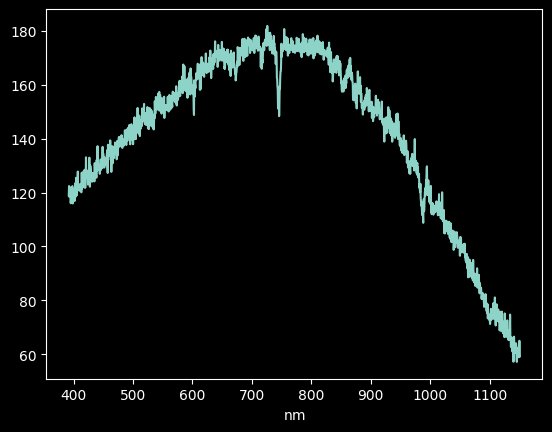

In [274]:
plt.plot(wavelengths_hg_deneb, spectro_deneb)

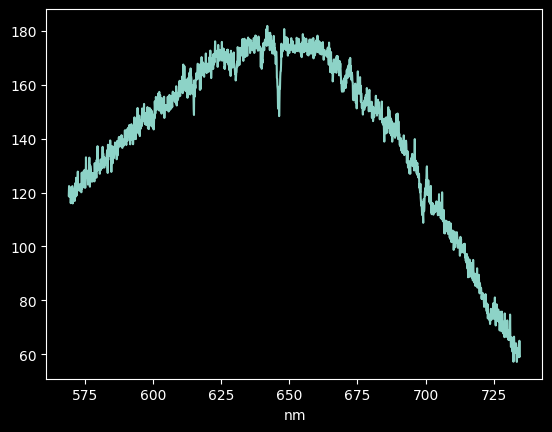

In [275]:
plt.plot(wavelengths_ne_deneb, spectro_deneb)

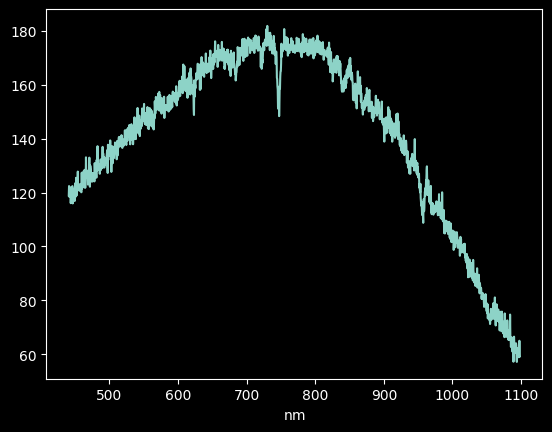

In [276]:
plt.plot(wavelengths_kr_deneb, spectro_deneb)

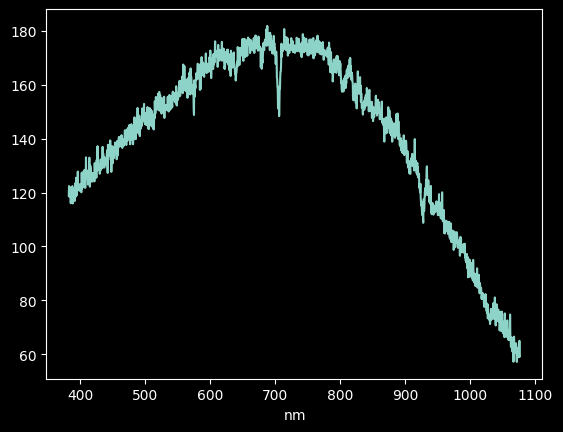

In [277]:
plt.plot(wavelengths_he_deneb, spectro_deneb)

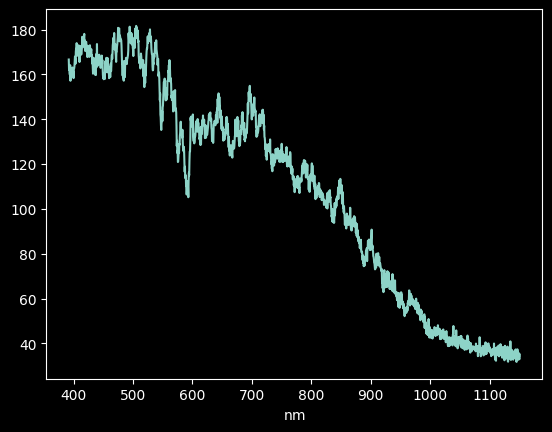

In [278]:
plt.plot(wavelengths_hg_aldebaran, spectro_aldebaran)

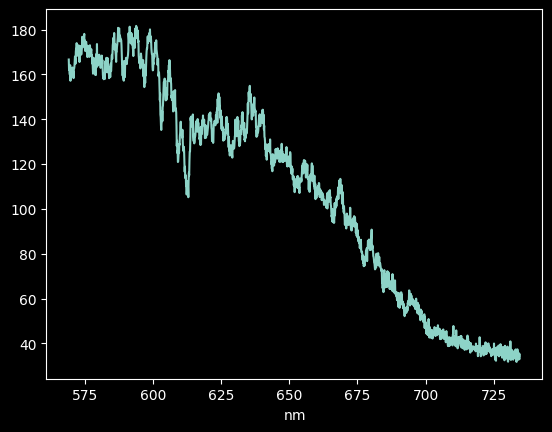

In [279]:
plt.plot(wavelengths_ne_aldebaran, spectro_aldebaran)

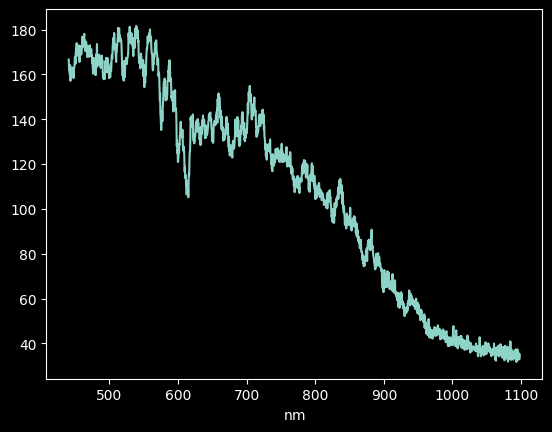

In [280]:
plt.plot(wavelengths_kr_aldebaran, spectro_aldebaran)

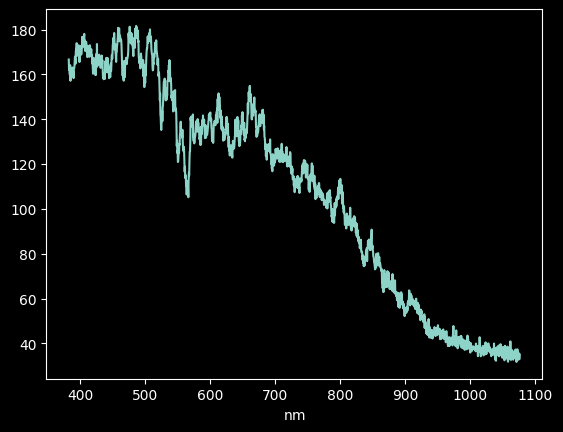

In [281]:
plt.plot(wavelengths_he_aldebaran, spectro_aldebaran)

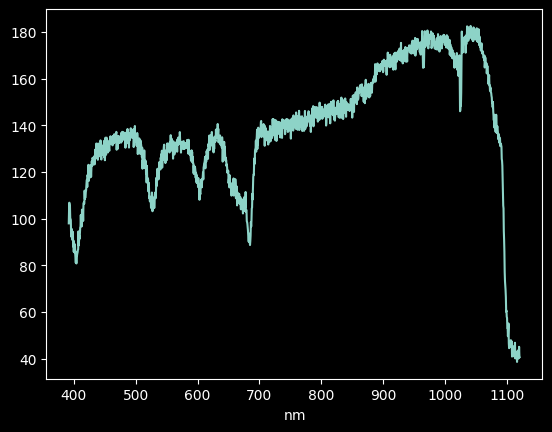

In [282]:
plt.plot(wavelengths_hg_vega, spectro_vega)

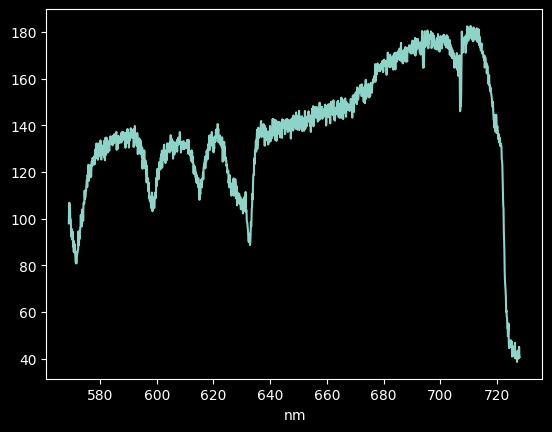

In [283]:
plt.plot(wavelengths_ne_vega, spectro_vega)

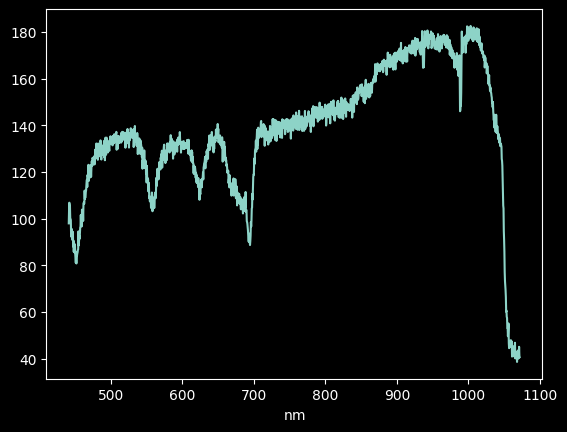

In [284]:
plt.plot(wavelengths_kr_vega, spectro_vega)

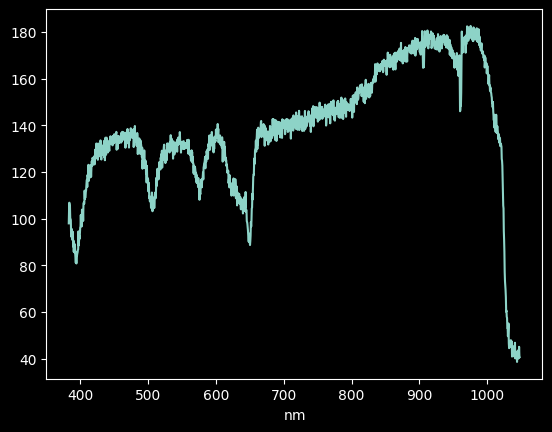

In [285]:
plt.plot(wavelengths_he_vega, spectro_vega)

# Analysis

Now, we go on to do some basic analysis on our fully extracted and wavelength-calibrated spectrum

We zoom in on the 4860 Angstrom line - H-Beta

(np.float64(700.0), np.float64(790.0), np.float64(140.0), np.float64(185.0))

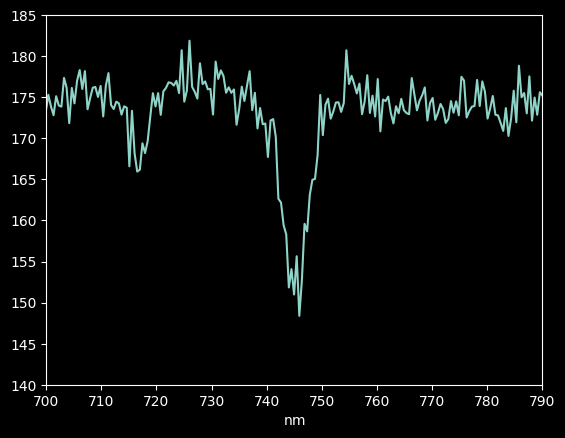

In [201]:
plt.plot(wavelengths_hg_deneb, spectro_deneb)
plt.axis([700,790, 140,185])

(np.float64(630.0), np.float64(660.0), np.float64(140.0), np.float64(185.0))

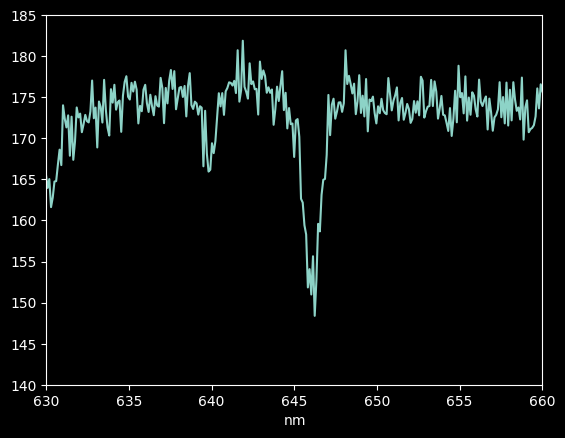

In [202]:
plt.plot(wavelengths_ne_deneb, spectro_deneb)
plt.axis([630,660, 140,185])

(np.float64(700.0), np.float64(790.0), np.float64(140.0), np.float64(185.0))

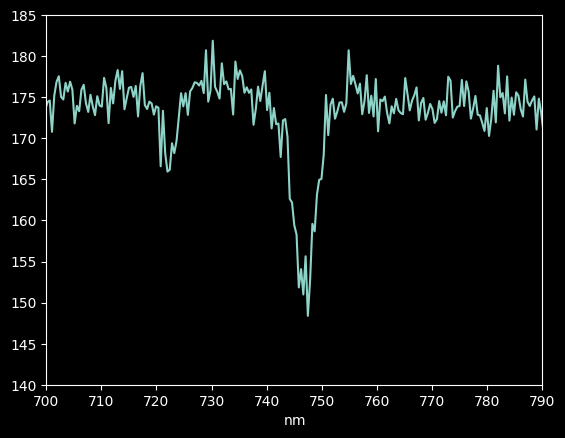

In [203]:
plt.plot(wavelengths_kr_deneb, spectro_deneb)
plt.axis([700,790, 140,185])

(np.float64(670.0), np.float64(740.0), np.float64(140.0), np.float64(185.0))

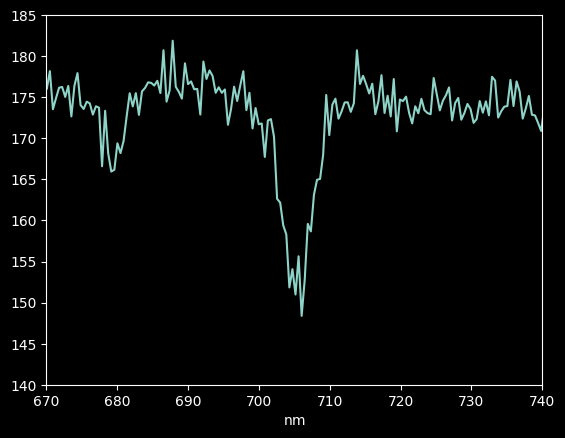

In [204]:
plt.plot(wavelengths_he_deneb, spectro_deneb)
plt.axis([670,740, 140,185])

(np.float64(520.0), np.float64(670.0), np.float64(100.0), np.float64(170.0))

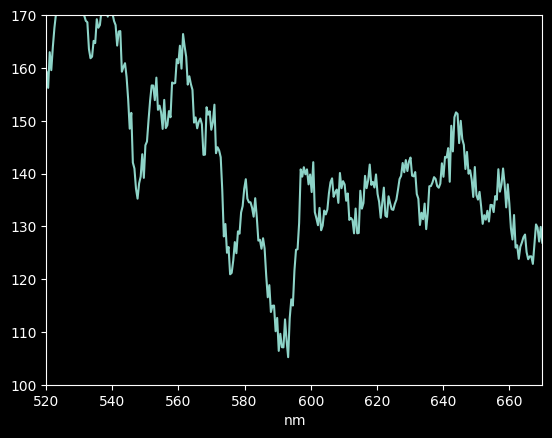

In [326]:
plt.plot(wavelengths_hg_aldebaran, spectro_aldebaran)
plt.axis([520,670, 100,170])

(np.float64(590.0), np.float64(635.0), np.float64(100.0), np.float64(170.0))

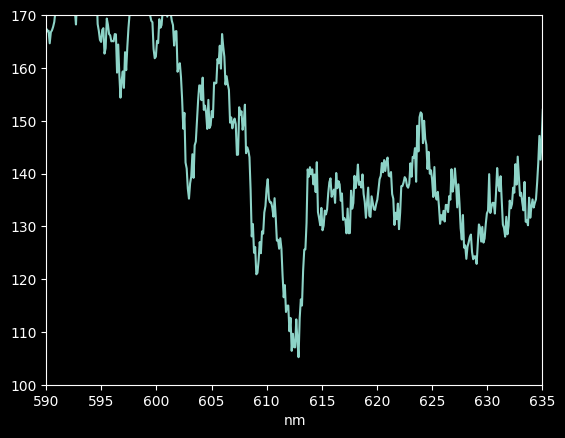

In [327]:
plt.plot(wavelengths_ne_aldebaran, spectro_aldebaran)
plt.axis([590,635, 100,170])

(np.float64(550.0), np.float64(685.0), np.float64(100.0), np.float64(170.0))

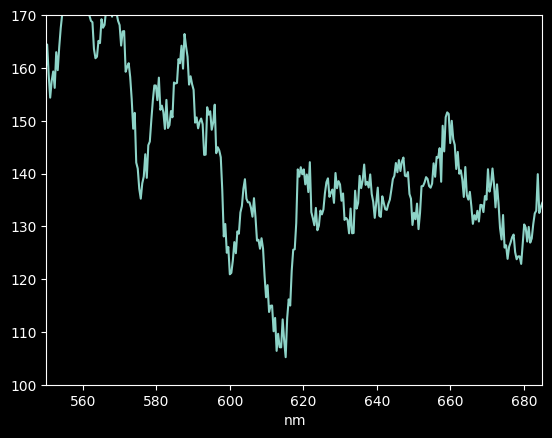

In [332]:
plt.plot(wavelengths_kr_aldebaran, spectro_aldebaran)
plt.axis([550,685,100,170])

(np.float64(510.0), np.float64(620.0), np.float64(100.0), np.float64(170.0))

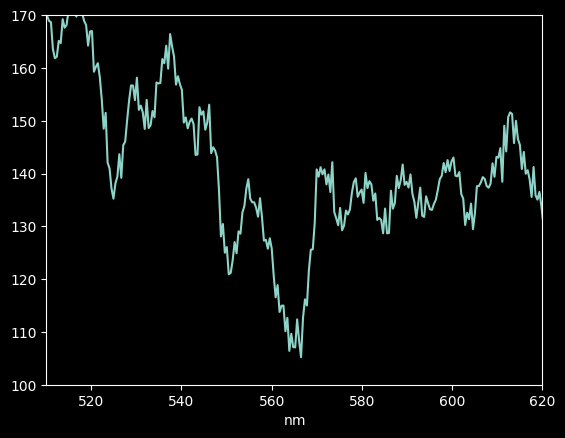

In [334]:
plt.plot(wavelengths_he_aldebaran, spectro_aldebaran)
plt.axis([510,620, 100,170])

(np.float64(620.0), np.float64(730.0), np.float64(80.0), np.float64(145.0))

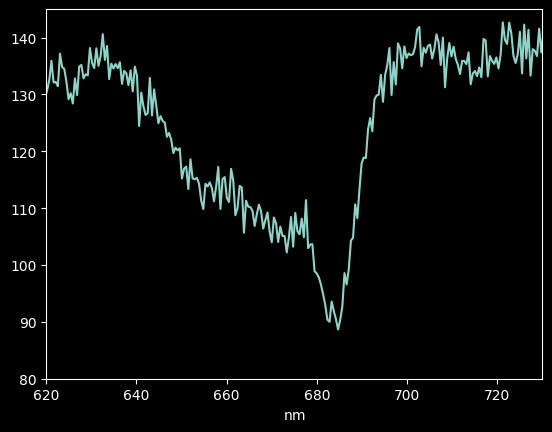

In [396]:
plt.plot(wavelengths_hg_vega, spectro_vega)
plt.axis([620,730, 80,145])

(np.float64(620.0), np.float64(645.0), np.float64(80.0), np.float64(145.0))

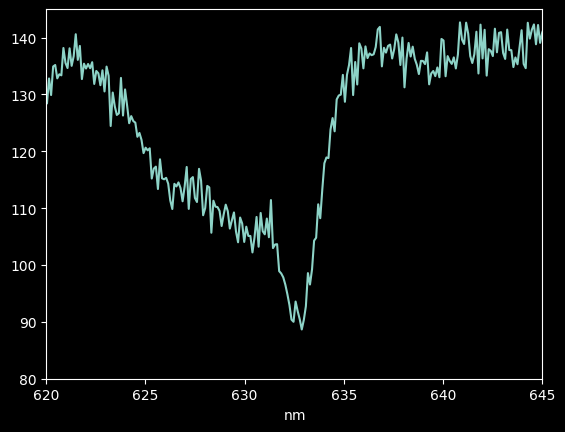

In [397]:
plt.plot(wavelengths_ne_vega, spectro_vega)
plt.axis([620,645, 80,145])

(np.float64(640.0), np.float64(740.0), np.float64(80.0), np.float64(145.0))

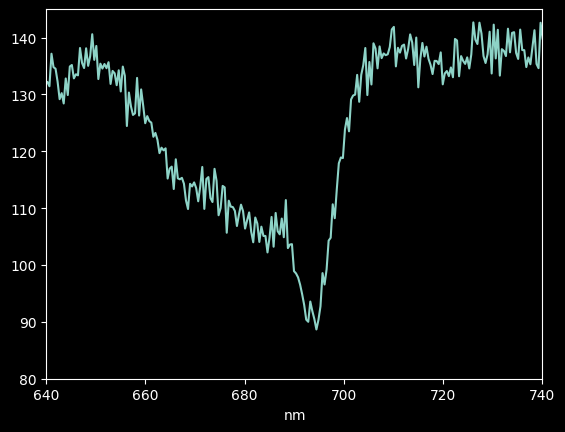

In [307]:
plt.plot(wavelengths_kr_vega, spectro_vega)
plt.axis([640,740, 80,145])

(np.float64(600.0), np.float64(690.0), np.float64(80.0), np.float64(145.0))

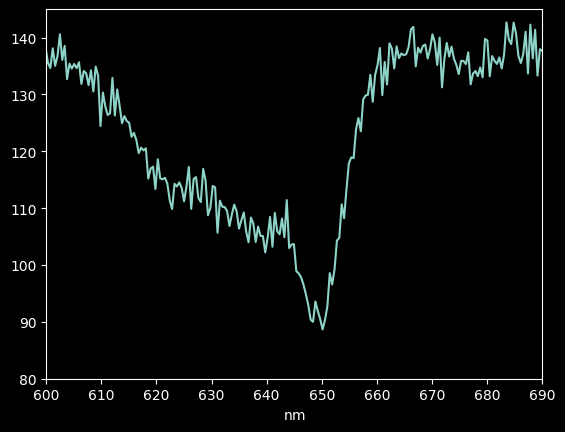

In [315]:
plt.plot(wavelengths_he_vega, spectro_vega)
plt.axis([600,690, 80,145])

We can use astropy models to construct an absorption line model, consisting of a continuum level and a negative Gaussian to represent the absorption feature

In [316]:
absorption_model_guess_hg_deneb = Linear1D(slope=0, intercept=175) + Gaussian1D(amplitude=-25, mean=745, stddev=2)

In [317]:
absorption_model_guess_ne_deneb = Linear1D(slope=0, intercept=175) + Gaussian1D(amplitude=-25, mean=646.5, stddev=2)

In [318]:
absorption_model_guess_kr_deneb = Linear1D(slope=0, intercept=175) + Gaussian1D(amplitude=-25, mean=746.5, stddev=2)

In [319]:
absorption_model_guess_he_deneb = Linear1D(slope=0, intercept=175) + Gaussian1D(amplitude=-25, mean=705, stddev=2)

In [393]:
absorption_model_guess_hg_aldebaran = Linear1D(slope=0, intercept=140) + Gaussian1D(amplitude=-38, mean=590, stddev=2)

In [386]:
absorption_model_guess_ne_aldebaran = Linear1D(slope=0, intercept=140) + Gaussian1D(amplitude=-38, mean=612.5, stddev=2)

In [364]:
absorption_model_guess_kr_aldebaran = Linear1D(slope=0, intercept=140) + Gaussian1D(amplitude=-38, mean=612, stddev=2)

In [367]:
absorption_model_guess_he_aldebaran = Linear1D(slope=0, intercept=140) + Gaussian1D(amplitude=-38, mean=565, stddev=2)

In [395]:
absorption_model_guess_hg_vega = Linear1D(slope=0, intercept=138) + Gaussian1D(amplitude=-50, mean=685, stddev=2)

In [398]:
absorption_model_guess_ne_vega = Linear1D(slope=0, intercept=138) + Gaussian1D(amplitude=-50, mean=632.5, stddev=2)

In [399]:
absorption_model_guess_kr_vega = Linear1D(slope=0, intercept=138) + Gaussian1D(amplitude=-50, mean=693, stddev=2)

In [400]:
absorption_model_guess_he_vega = Linear1D(slope=0, intercept=138) + Gaussian1D(amplitude=-50, mean=650, stddev=2)

We can overplot our guessed model - it's not right, but it's in the right spot

(np.float64(700.0), np.float64(790.0), np.float64(140.0), np.float64(185.0))

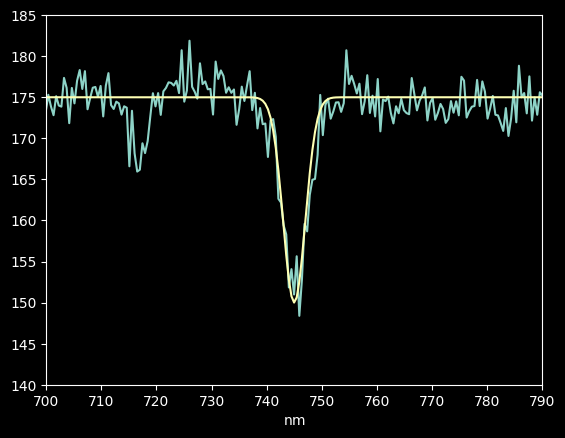

In [205]:
plt.plot(wavelengths_hg_deneb, spectro_deneb)
plt.plot(wavelengths_hg_deneb, absorption_model_guess_hg_deneb(wavelengths_hg_deneb.value))
plt.axis([700,790, 140,185])

(np.float64(630.0), np.float64(660.0), np.float64(140.0), np.float64(185.0))

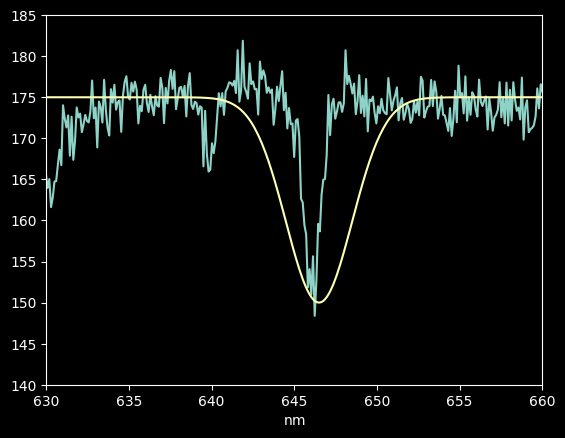

In [206]:
plt.plot(wavelengths_ne_deneb, spectro_deneb)
plt.plot(wavelengths_ne_deneb, absorption_model_guess_ne_deneb(wavelengths_ne_deneb.value))
plt.axis([630,660, 140,185])

(np.float64(700.0), np.float64(790.0), np.float64(140.0), np.float64(185.0))

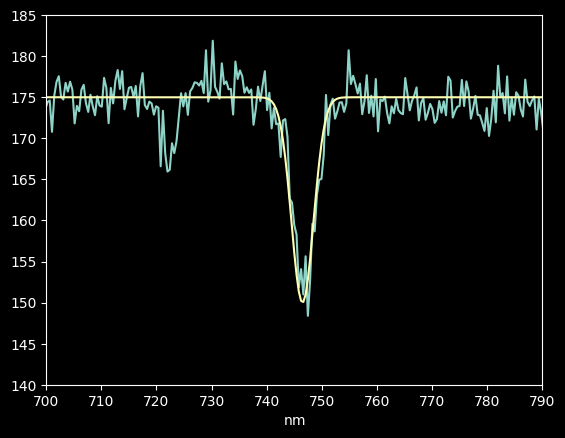

In [207]:
plt.plot(wavelengths_kr_deneb, spectro_deneb)
plt.plot(wavelengths_kr_deneb, absorption_model_guess_kr_deneb(wavelengths_kr_deneb.value))
plt.axis([700,790, 140,185])

(np.float64(670.0), np.float64(740.0), np.float64(140.0), np.float64(185.0))

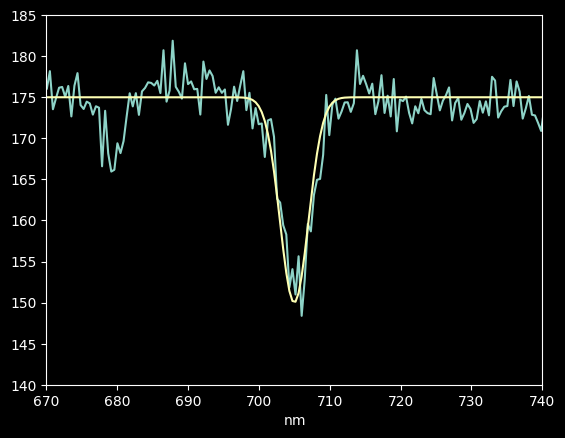

In [355]:
plt.plot(wavelengths_he_deneb, spectro_deneb)
plt.plot(wavelengths_he_deneb, absorption_model_guess_he_deneb(wavelengths_he_deneb.value))
plt.axis([670,740, 140,185])

(np.float64(520.0), np.float64(670.0), np.float64(100.0), np.float64(170.0))

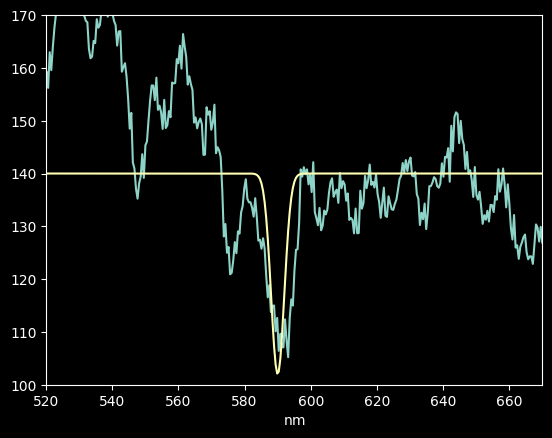

In [394]:
plt.plot(wavelengths_hg_aldebaran, spectro_aldebaran)
plt.plot(wavelengths_hg_aldebaran, absorption_model_guess_hg_aldebaran(wavelengths_hg_aldebaran.value))
plt.axis([520,670, 100,170])

(np.float64(590.0), np.float64(635.0), np.float64(100.0), np.float64(170.0))

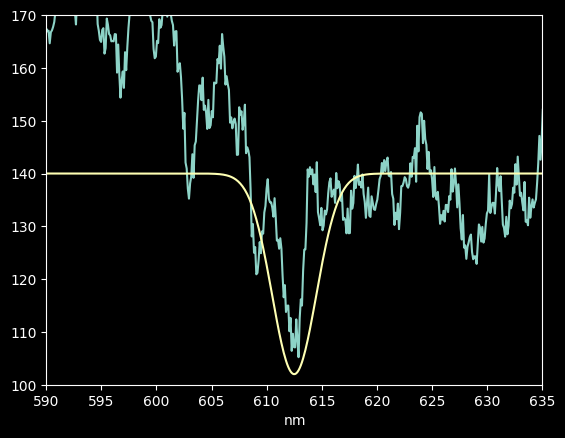

In [357]:
plt.plot(wavelengths_ne_aldebaran, spectro_aldebaran)
plt.plot(wavelengths_ne_aldebaran, absorption_model_guess_ne_aldebaran(wavelengths_ne_aldebaran.value))
plt.axis([590,635, 100,170])

(np.float64(550.0), np.float64(685.0), np.float64(100.0), np.float64(170.0))

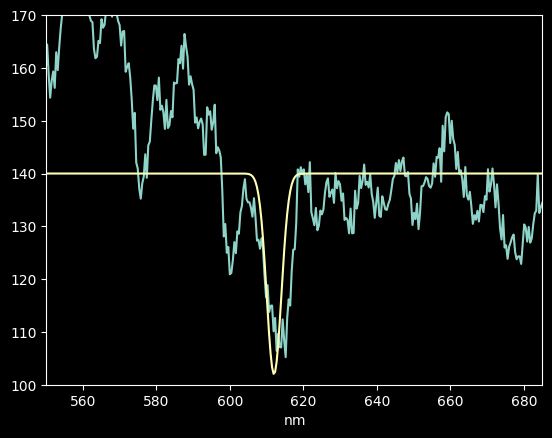

In [365]:
plt.plot(wavelengths_kr_aldebaran, spectro_aldebaran)
plt.plot(wavelengths_kr_aldebaran, absorption_model_guess_kr_aldebaran(wavelengths_kr_aldebaran.value))
plt.axis([550,685, 100,170])

(np.float64(510.0), np.float64(620.0), np.float64(100.0), np.float64(170.0))

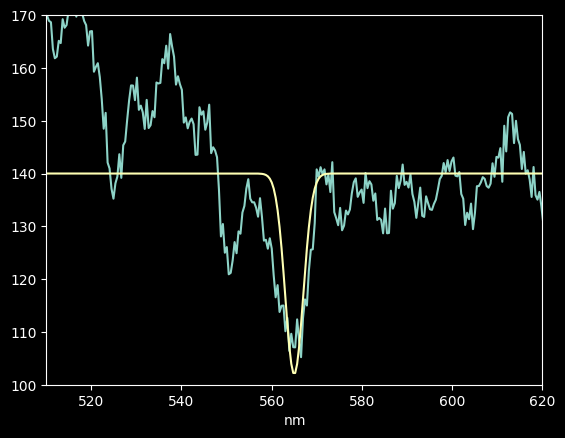

In [368]:
plt.plot(wavelengths_he_aldebaran, spectro_aldebaran)
plt.plot(wavelengths_he_aldebaran, absorption_model_guess_he_aldebaran(wavelengths_he_aldebaran.value))
plt.axis([510,620, 100,170])

(np.float64(620.0), np.float64(730.0), np.float64(80.0), np.float64(145.0))

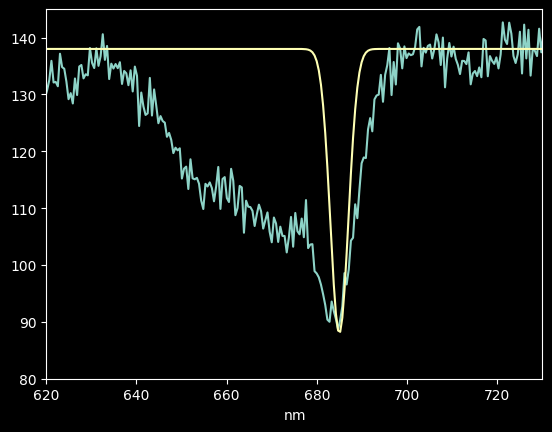

In [402]:
plt.plot(wavelengths_hg_vega, spectro_vega)
plt.plot(wavelengths_hg_vega, absorption_model_guess_hg_vega(wavelengths_hg_vega.value))
plt.axis([620,730, 80,145])

(np.float64(620.0), np.float64(645.0), np.float64(80.0), np.float64(145.0))

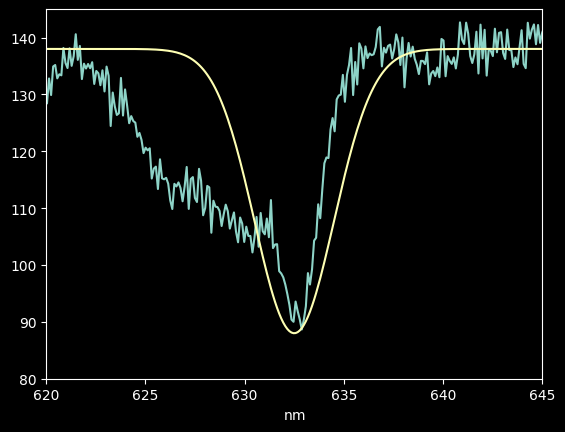

In [403]:
plt.plot(wavelengths_ne_vega, spectro_vega)
plt.plot(wavelengths_ne_vega, absorption_model_guess_ne_vega(wavelengths_ne_vega.value))
plt.axis([620,645, 80,145])

(np.float64(640.0), np.float64(740.0), np.float64(80.0), np.float64(145.0))

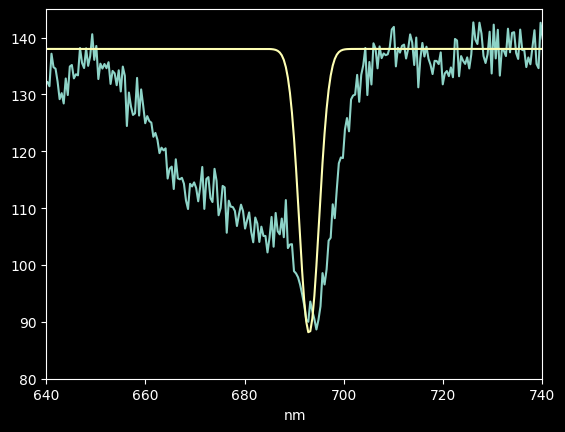

In [404]:
plt.plot(wavelengths_kr_vega, spectro_vega)
plt.plot(wavelengths_kr_vega, absorption_model_guess_kr_vega(wavelengths_kr_vega.value))
plt.axis([640,740, 80,145])

(np.float64(600.0), np.float64(690.0), np.float64(80.0), np.float64(145.0))

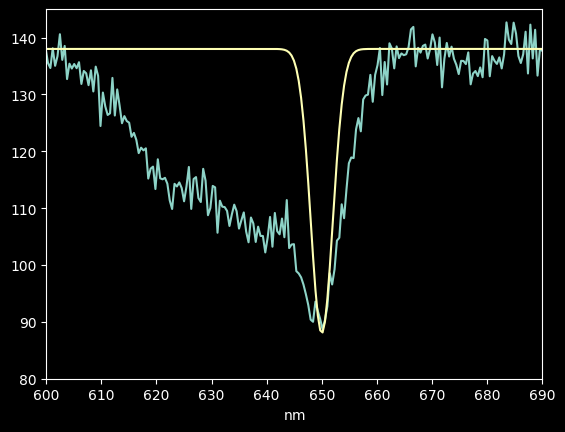

In [405]:
plt.plot(wavelengths_he_vega, spectro_vega)
plt.plot(wavelengths_he_vega, absorption_model_guess_he_vega(wavelengths_he_vega.value))
plt.axis([600,690, 80,145])

The Levenberg-Marquardt Least Squares fitter can be used to find the optimal fit to our data given the starting guess.

In [209]:
lmfitter = LevMarLSQFitter()
selection_hg_deneb = (wavelengths_hg_deneb > 700*u.nm) & (wavelengths_hg_deneb < 790*u.nm) 
fitted_absorption_model_hg_deneb = lmfitter(model=absorption_model_guess_hg_deneb, x=wavelengths_hg_deneb.value[selection_hg_deneb], y=spectro_deneb[selection_hg_deneb])

In [210]:
lmfitter = LevMarLSQFitter()
selection_ne_deneb = (wavelengths_ne_deneb > 630*u.nm) & (wavelengths_ne_deneb < 660*u.nm) 
fitted_absorption_model_ne_deneb = lmfitter(model=absorption_model_guess_ne_deneb, x=wavelengths_ne_deneb.value[selection_ne_deneb], y=spectro_deneb[selection_ne_deneb])

In [211]:
lmfitter = LevMarLSQFitter()
selection_kr_deneb = (wavelengths_kr_deneb > 700*u.nm) & (wavelengths_kr_deneb < 790*u.nm) 
fitted_absorption_model_kr_deneb = lmfitter(model=absorption_model_guess_kr_deneb, x=wavelengths_kr_deneb.value[selection_kr_deneb], y=spectro_deneb[selection_kr_deneb])

In [119]:
lmfitter = LevMarLSQFitter()
selection_he_deneb = (wavelengths_he_deneb > 670*u.nm) & (wavelengths_he_deneb < 740*u.nm) 
fitted_absorption_model_he_deneb = lmfitter(model=absorption_model_guess_he_deneb, x=wavelengths_he_deneb.value[selection_he_deneb], y=spectrum2[selection_he_deneb])

In [372]:
lmfitter = LevMarLSQFitter()
selection_hg_aldebaran = (wavelengths_hg_aldebaran > 520*u.nm) & (wavelengths_hg_aldebaran < 660*u.nm) 
fitted_absorption_model_hg_aldebaran = lmfitter(model=absorption_model_guess_hg_aldebaran, x=wavelengths_hg_aldebaran.value[selection_hg_aldebaran], y=spectro_aldebaran[selection_hg_aldebaran])

In [373]:
lmfitter = LevMarLSQFitter()
selection_ne_aldebaran = (wavelengths_ne_aldebaran > 590*u.nm) & (wavelengths_ne_aldebaran < 635*u.nm) 
fitted_absorption_model_ne_aldebaran = lmfitter(model=absorption_model_guess_ne_aldebaran, x=wavelengths_ne_aldebaran.value[selection_ne_aldebaran], y=spectro_aldebaran[selection_ne_aldebaran])

In [374]:
lmfitter = LevMarLSQFitter()
selection_kr_aldebaran = (wavelengths_kr_aldebaran > 550*u.nm) & (wavelengths_kr_aldebaran < 685*u.nm) 
fitted_absorption_model_kr_aldebaran = lmfitter(model=absorption_model_guess_kr_aldebaran, x=wavelengths_kr_aldebaran.value[selection_kr_aldebaran], y=spectro_aldebaran[selection_kr_aldebaran])

In [375]:
lmfitter = LevMarLSQFitter()
selection_he_aldebaran = (wavelengths_he_aldebaran > 510*u.nm) & (wavelengths_he_aldebaran < 620*u.nm) 
fitted_absorption_model_he_aldebaran = lmfitter(model=absorption_model_guess_he_aldebaran, x=wavelengths_he_aldebaran.value[selection_he_aldebaran], y=spectro_aldebaran[selection_he_aldebaran])

In [406]:
lmfitter = LevMarLSQFitter()
selection_hg_vega = (wavelengths_hg_vega > 620*u.nm) & (wavelengths_hg_vega < 730*u.nm) 
fitted_absorption_model_hg_vega = lmfitter(model=absorption_model_guess_hg_vega, x=wavelengths_hg_vega.value[selection_hg_vega], y=spectro_vega[selection_hg_vega])

In [407]:
lmfitter = LevMarLSQFitter()
selection_ne_vega = (wavelengths_ne_vega > 620*u.nm) & (wavelengths_ne_vega < 645*u.nm) 
fitted_absorption_model_ne_vega = lmfitter(model=absorption_model_guess_ne_vega, x=wavelengths_ne_vega.value[selection_ne_vega], y=spectro_vega[selection_ne_vega])

In [408]:
lmfitter = LevMarLSQFitter()
selection_kr_vega = (wavelengths_kr_vega > 640*u.nm) & (wavelengths_kr_vega < 740*u.nm) 
fitted_absorption_model_kr_vega = lmfitter(model=absorption_model_guess_kr_vega, x=wavelengths_kr_vega.value[selection_kr_vega], y=spectro_vega[selection_kr_vega])

In [409]:
lmfitter = LevMarLSQFitter()
selection_he_vega = (wavelengths_he_vega > 600*u.nm) & (wavelengths_he_vega < 690*u.nm) 
fitted_absorption_model_he_vega = lmfitter(model=absorption_model_guess_he_vega, x=wavelengths_he_vega.value[selection_he_vega], y=spectro_vega[selection_he_vega])

(np.float64(700.0), np.float64(790.0), np.float64(140.0), np.float64(185.0))

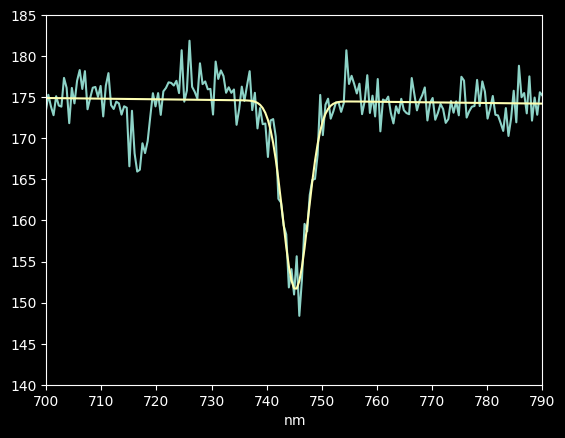

In [212]:
plt.plot(wavelengths_hg_deneb, spectro_deneb)
plt.plot(wavelengths_hg_deneb, fitted_absorption_model_hg_deneb(wavelengths_hg_deneb.value))
plt.axis([700,790, 140,185])

(np.float64(630.0), np.float64(660.0), np.float64(140.0), np.float64(185.0))

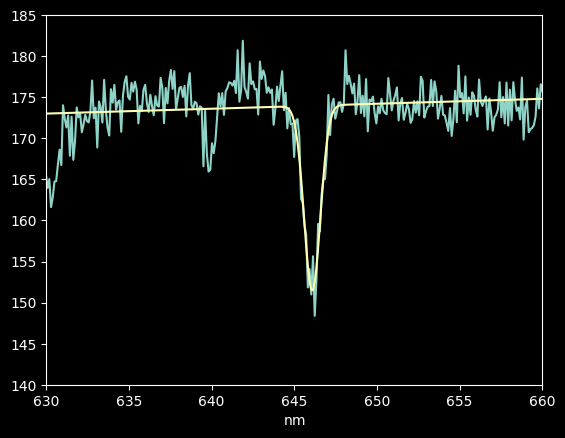

In [213]:
plt.plot(wavelengths_ne_deneb, spectro_deneb)
plt.plot(wavelengths_ne_deneb, fitted_absorption_model_ne_deneb(wavelengths_ne_deneb.value))
plt.axis([630,660, 140,185])

(np.float64(700.0), np.float64(790.0), np.float64(140.0), np.float64(185.0))

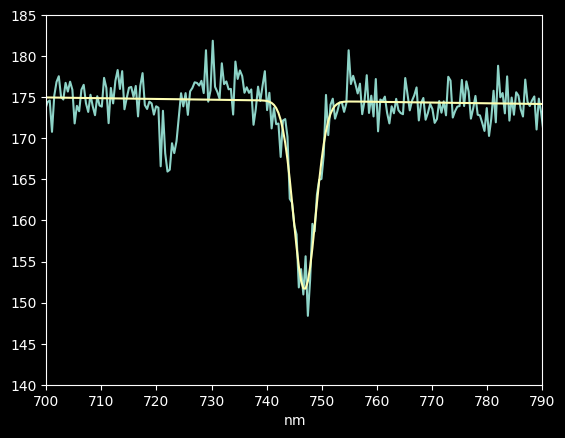

In [214]:
plt.plot(wavelengths_kr_deneb, spectro_deneb)
plt.plot(wavelengths_kr_deneb, fitted_absorption_model_kr_deneb(wavelengths_kr_deneb.value))
plt.axis([700,790, 140,185])

(np.float64(670.0), np.float64(740.0), np.float64(140.0), np.float64(185.0))

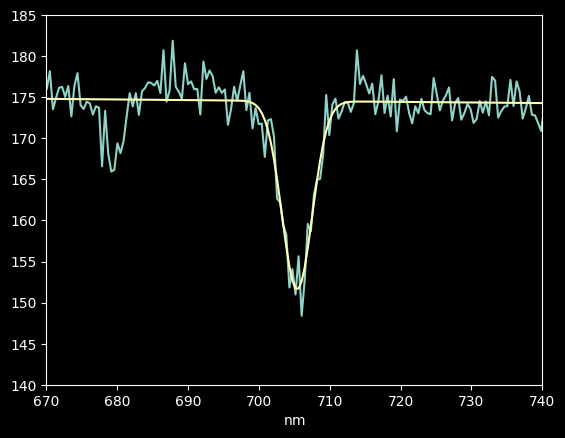

In [216]:
plt.plot(wavelengths_he_deneb, spectro_deneb)
plt.plot(wavelengths_he_deneb, fitted_absorption_model_he_deneb(wavelengths_he_deneb.value))
plt.axis([670,740, 140,185])

(np.float64(510.0), np.float64(650.0), np.float64(100.0), np.float64(170.0))

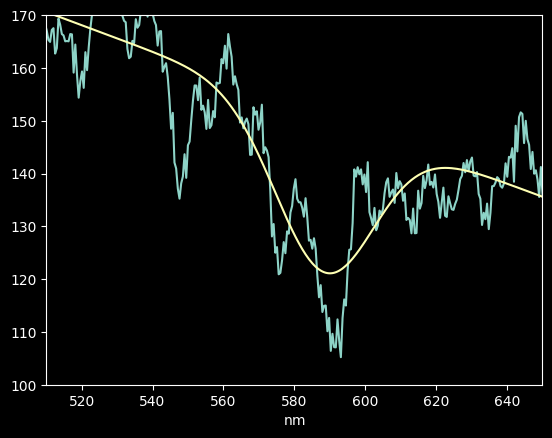

In [389]:
plt.plot(wavelengths_hg_aldebaran, spectro_aldebaran)
plt.plot(wavelengths_hg_aldebaran, fitted_absorption_model_hg_aldebaran(wavelengths_hg_aldebaran.value))
plt.axis([510,650, 100,170])

(np.float64(590.0), np.float64(635.0), np.float64(100.0), np.float64(170.0))

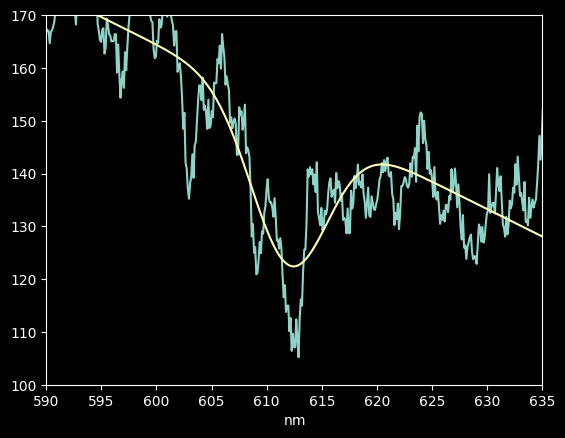

In [384]:
plt.plot(wavelengths_ne_aldebaran, spectro_aldebaran)
plt.plot(wavelengths_ne_aldebaran, fitted_absorption_model_ne_aldebaran(wavelengths_ne_aldebaran.value))
plt.axis([590,635, 100,170])

(np.float64(550.0), np.float64(685.0), np.float64(100.0), np.float64(170.0))

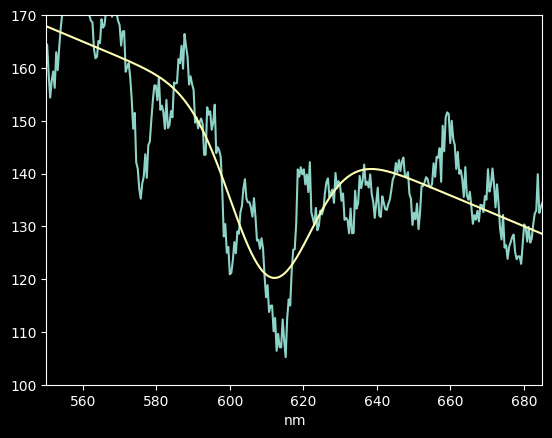

In [388]:
plt.plot(wavelengths_kr_aldebaran, spectro_aldebaran)
plt.plot(wavelengths_kr_aldebaran, fitted_absorption_model_kr_aldebaran(wavelengths_kr_aldebaran.value))
plt.axis([550, 685, 100,170])

(np.float64(510.0), np.float64(620.0), np.float64(100.0), np.float64(170.0))

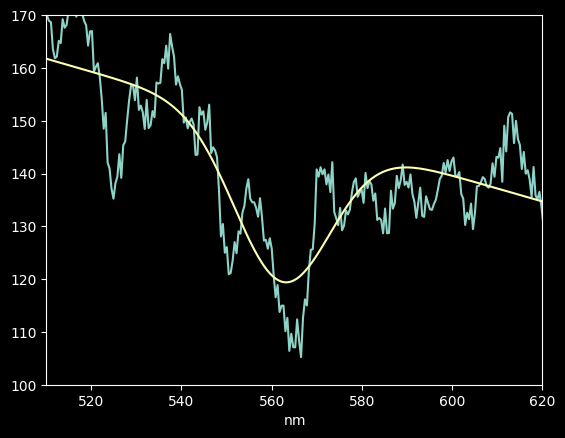

In [390]:
plt.plot(wavelengths_he_aldebaran, spectro_aldebaran)
plt.plot(wavelengths_he_aldebaran, fitted_absorption_model_he_aldebaran(wavelengths_he_aldebaran.value))
plt.axis([510,620, 100,170])

(np.float64(620.0), np.float64(730.0), np.float64(80.0), np.float64(145.0))

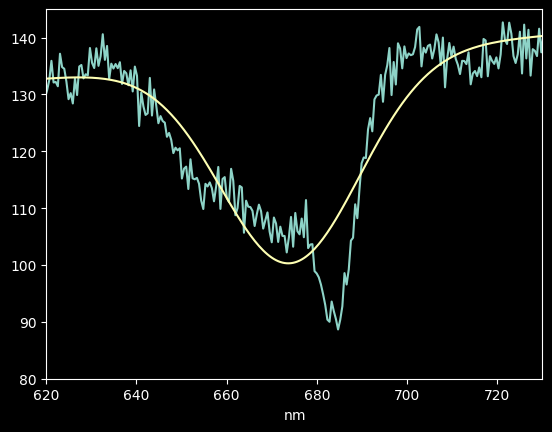

In [410]:
plt.plot(wavelengths_hg_vega, spectro_vega)
plt.plot(wavelengths_hg_vega, fitted_absorption_model_hg_vega(wavelengths_hg_vega.value))
plt.axis([620,730, 80,145])

(np.float64(620.0), np.float64(645.0), np.float64(80.0), np.float64(145.0))

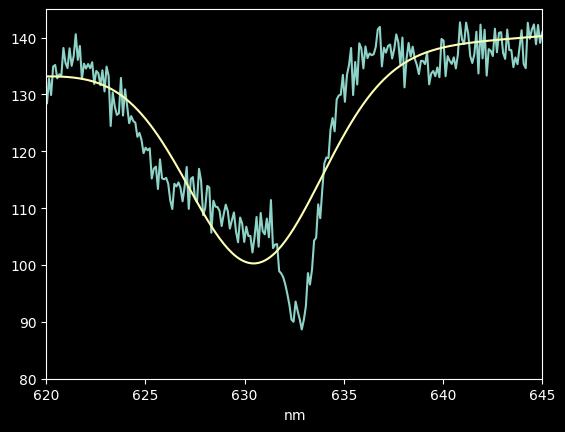

In [411]:
plt.plot(wavelengths_ne_vega, spectro_vega)
plt.plot(wavelengths_ne_vega, fitted_absorption_model_ne_vega(wavelengths_ne_vega.value))
plt.axis([620,645, 80,145])

(np.float64(640.0), np.float64(740.0), np.float64(80.0), np.float64(145.0))

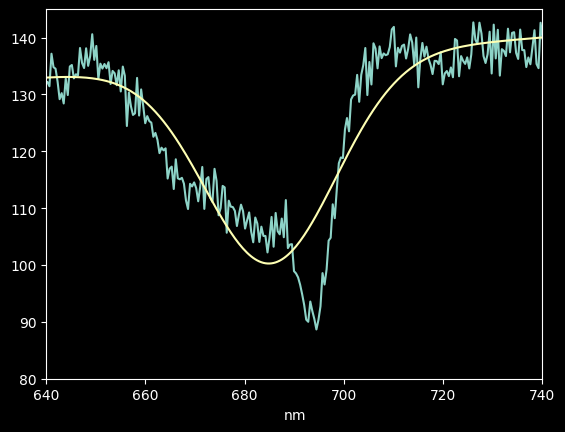

In [412]:
plt.plot(wavelengths_kr_vega, spectro_vega)
plt.plot(wavelengths_kr_vega, fitted_absorption_model_kr_vega(wavelengths_kr_vega.value))
plt.axis([640,740, 80,145])

(np.float64(600.0), np.float64(690.0), np.float64(80.0), np.float64(145.0))

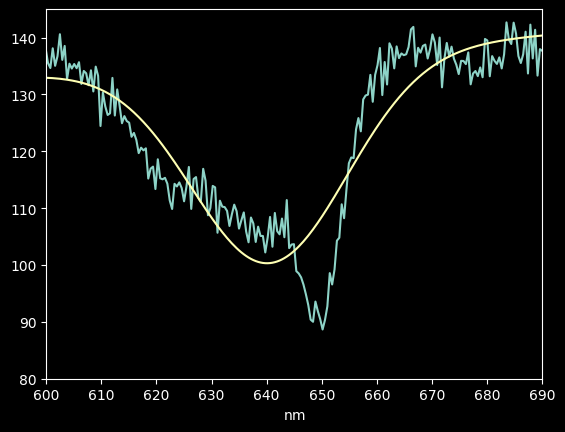

In [413]:
plt.plot(wavelengths_he_vega, spectro_vega)
plt.plot(wavelengths_he_vega, fitted_absorption_model_he_vega(wavelengths_he_vega.value))
plt.axis([600,690, 80,145])

That's it!  You've extracted and wavelength-calibrated a spectrum.